In [1]:
from pathlib import Path
from paquo.projects import QuPathProject

project_path = Path(r"C:\Users\Vivian\Desktop\paquo_test.qpproj")

with QuPathProject(project_path, mode="w") as qp:
    print("Created project at:", qp.path)


backing up Desktop before truncating! (this can be disabled via PAQUO_SAFE_TRUNCATE)


Created project at: C:\Users\Vivian\Desktop\project.qpproj


In [2]:
from paquo.projects import QuPathProject

qp = QuPathProject(r"C:\Users\Vivian\Documents\qupath_ann_testing\project.qpproj")

In [3]:
import pandas as pd
# qp = QuPathProject('./my_new_project/project.qpproj', mode='r')  # open an existing project
image = qp.images[0]  # get the first image
detections = image.hierarchy.detections  # detections are stored in a set like proxy object
df = pd.DataFrame(detection.measurements for detection in detections)  # put the measurements dictionary for each detection into a pandas DataFrame

In [ ]:
df.head()

automated cell detection

iterating over all patches in slide

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from tifffile import imwrite
import subprocess, tempfile, textwrap

QUPath_EXE = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection.groovy" # entire slide
# GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection_stroma_only.groovy" # stroma only

def run_cell_detection_on_npy(npy_path):
    npy_path = Path(npy_path)
    arr = np.load(npy_path)

    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        tiff_path = tmpdir / "temp_patch.tif"
        imwrite(tiff_path, arr)

        cmd = [
            QUPath_EXE,
            "script",
            str(GROOVY_SCRIPT),
            f"--image={tiff_path}",
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            cwd=tmpdir,
        )

        if result.returncode != 0:
            print("STDOUT:\n", textwrap.indent(result.stdout or "", "  "))
            print("STDERR:\n", textwrap.indent(result.stderr or "", "  "))
            raise RuntimeError("QuPath failed")

        out_tsv = tmpdir / "temp_patch_cells.tsv"
        df = pd.read_csv(out_tsv, sep="\t")

    # tag with patch identity
    df["patch_path"] = str(npy_path)
    df["patch_name"] = npy_path.stem
    return df


In [24]:
from glob import glob

patch_dir = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B"
# patch_dir = r'C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\FA\FA 67 B'
# patch_dir = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 42 B"

patch_paths = sorted(glob(str(Path(patch_dir) / "*.npy")))

all_cells = []

for patch_idx, p in enumerate(patch_paths):
    print(f"Processing patch_idx={patch_idx}: {p}")
    df_cells = run_cell_detection_on_npy(p)
    df_cells["patch_idx"] = patch_idx  # <- index for this patch
    all_cells.append(df_cells)

df_all_cells = pd.concat(all_cells, ignore_index=True)


Processing patch_idx=0: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_0_x4032_y0.npy
Processing patch_idx=1: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_100_x5824_y1120.npy
Processing patch_idx=2: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_101_x6048_y1120.npy
Processing patch_idx=3: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_102_x6272_y1120.npy
Processing patch_idx=4: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_103_x6496_y1120.npy
Processing patch_idx=5: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_104_x6720_y1120.npy
Processing patch_idx=6: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_105_x448_y1344.npy
Processing patch_idx=7: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_106_x672_y1344.npy
Processing patch_idx=8: C:\Users\Vivian

In [ ]:
out_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B_272um.csv"
df_all_cells.to_csv(out_csv, index=False)


include cell annotation

In [1]:
import json
import json
from pathlib import Path
import numpy as np
import pandas as pd
from tifffile import imwrite
import subprocess, tempfile, textwrap

QUPath_EXE = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection_ann.groovy" # entire slide
# GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection_stroma_only.groovy" # stroma only


def run_cell_detection_on_npy(npy_path):
    npy_path = Path(npy_path)
    arr = np.load(npy_path)

    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        tiff_path = tmpdir / "temp_patch.tif"
        imwrite(tiff_path, arr)

        cmd = [
            QUPath_EXE,
            "script",
            str(GROOVY_SCRIPT),
            f"--image={tiff_path}",
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            cwd=tmpdir,
        )

        if result.returncode != 0:
            print("STDOUT:\n", textwrap.indent(result.stdout or "", "  "))
            print("STDERR:\n", textwrap.indent(result.stderr or "", "  "))
            raise RuntimeError("QuPath failed")

        # Load cell TSV
        out_tsv = tmpdir / "temp_patch_cells.tsv"
        df = pd.read_csv(out_tsv, sep="\t")

        # Load GeoJSON nuclei polygons (if present)
        geojson_path = tmpdir / "temp_patch_nuclei.geojson"
        polygons = None
        if geojson_path.exists():
            with open(geojson_path, "r") as f:
                polygons = json.load(f)

    # Add metadata BEFORE returning
    df["patch_path"] = str(npy_path)
    df["patch_name"] = npy_path.stem

    return df, polygons


In [18]:
from pathlib import Path
from glob import glob
import json
import pandas as pd

# patch_dir = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B"
patch_dir = r'C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B'
patch_paths = sorted(glob(str(Path(patch_dir) / "*.npy")))

slide_name = "PT_40_B"
slide_geojson_out = Path(r"C:\Users\Vivian\Documents\qupath_ann_testing\masks\10x") / f"{slide_name}_nuclei.geojson"
slide_geojson_out.parent.mkdir(parents=True, exist_ok=True)

all_cells = []
slide_features = []  # will hold all nuclei features for this slide

for patch_idx, p in enumerate(patch_paths):
    print(f"Processing patch_idx={patch_idx}: {p}")
    df_cells, polygons = run_cell_detection_on_npy(p)

    df_cells["patch_idx"] = patch_idx
    all_cells.append(df_cells)

    # Merge polygons into slide-level FeatureCollection
    if polygons is not None and "features" in polygons:
        patch_name = Path(p).stem
        for feat in polygons["features"]:
            # Ensure properties dict exists
            props = feat.get("properties", {}) or {}
            # Add patch-level metadata
            props["patch_path"] = str(p)
            props["patch_name"] = patch_name
            props["patch_idx"] = patch_idx
            feat["properties"] = props
            slide_features.append(feat)

# --- Save cell CSV (same as before) ---
df_all_cells = pd.concat(all_cells, ignore_index=True)
out_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_40_B_68um.csv"
df_all_cells.to_csv(out_csv, index=False)
print("Saved cell CSV:", out_csv)

# --- Save ONE GeoJSON per slide ---
slide_fc = {
    "type": "FeatureCollection",
    "features": slide_features,
}

with open(slide_geojson_out, "w") as f:
    json.dump(slide_fc, f, indent=2)

print("Saved slide-level nuclei GeoJSON:", slide_geojson_out)


Processing patch_idx=0: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_0_x4928_y1792.npy
Processing patch_idx=1: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1000_x14112_y8288.npy
Processing patch_idx=2: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1001_x13440_y8512.npy
Processing patch_idx=3: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1002_x13664_y8512.npy
Processing patch_idx=4: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1003_x13888_y8512.npy
Processing patch_idx=5: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1004_x14112_y8512.npy
Processing patch_idx=6: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1005_x14560_y7840.npy
Processing patch_idx=7: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_1006_x14784_y7840.npy
Proc

batch processing slides

In [1]:
import os
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
from tifffile import imwrite
import subprocess, tempfile, textwrap
from tqdm import tqdm

QUPath_EXE = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection.groovy"


def run_cell_detection_on_npy(npy_path):
    """
    Run QuPath cell detection on a single .npy patch.
    Returns a DataFrame of cells detected in that patch.
    """
    npy_path = Path(npy_path)
    arr = np.load(npy_path)

    # Ensure RGB uint8
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        tiff_path = tmpdir / "temp_patch.tif"
        imwrite(tiff_path, arr)

        cmd = [
            QUPath_EXE,
            "script",
            str(GROOVY_SCRIPT),
            f"--image={tiff_path}",
        ]

        result = subprocess.run(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            cwd=tmpdir,
        )

        if result.returncode != 0:
            print("STDOUT:\n", textwrap.indent(result.stdout or "", "  "))
            print("STDERR:\n", textwrap.indent(result.stderr or "", "  "))
            raise RuntimeError("QuPath failed")

        out_tsv = tmpdir / "temp_patch_cells.tsv"
        df = pd.read_csv(out_tsv, sep="\t")

    # tag with patch identity
    df["patch_path"] = str(npy_path)
    df["patch_name"] = npy_path.stem

    return df


# ==============================================================
# Iterate over slide directories with progress bars
# ==============================================================

root_dir = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA"
output_root = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x"

root_dir = Path(root_dir)
output_root = Path(output_root)
output_root.mkdir(parents=True, exist_ok=True)

slide_dirs = [d for d in root_dir.iterdir() if d.is_dir()]

print(f"Found {len(slide_dirs)} slide directories.")


for slide_dir in tqdm(slide_dirs, desc="Slides processed", unit="slide"):
    slide_name = slide_dir.name.replace(" ", "_")
    csv_path = output_root / f"{slide_name}.csv"

    # Skip if CSV already exists
    if csv_path.exists():
        tqdm.write(f"[SKIP] {slide_name} → CSV already exists.")
        continue

    patch_paths = sorted(slide_dir.glob("*.npy"))

    if len(patch_paths) == 0:
        tqdm.write(f"[SKIP] {slide_name}: no .npy patches found.")
        continue

    tqdm.write(f"[START] Processing {slide_name}, {len(patch_paths)} patches.")

    all_cells = []

    # Progress bar for patches within each slide
    for patch_idx, p in enumerate(tqdm(patch_paths, desc=f"{slide_name}", leave=False)):
        df_cells = run_cell_detection_on_npy(p)
        df_cells["patch_idx"] = patch_idx
        all_cells.append(df_cells)

    # Concatenate all cells
    df_all_cells = pd.concat(all_cells, ignore_index=True)

    # Save CSV
    df_all_cells.to_csv(csv_path, index=False)
    tqdm.write(f"[DONE] Saved {csv_path}")


Found 24 slide directories.


Slides processed:   0%|          | 0/24 [00:00<?, ?slide/s]

[SKIP] FA_56B → CSV already exists.
[START] Processing FA_57B, 554 patches.


Slides processed:   8%|▊         | 2/24 [20:46<3:48:28, 623.13s/slide]

[DONE] Saved C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B.csv
[START] Processing FA_58B, 523 patches.


...

[DONE] Saved C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_85_B.csv
[START] Processing FA_86_B, 684 patches.


Slides processed:  96%|█████████▌| 23/24 [8:50:33<24:08, 1448.99s/slide]

[DONE] Saved C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_86_B.csv
[START] Processing FA_88_B, 25 patches.


Slides processed: 100%|██████████| 24/24 [8:51:29<00:00, 1328.72s/slide]

[DONE] Saved C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_88_B.csv


generate heatmap

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --------------------------------------------- 
# Heatmap based on cell count per patch
# --------------------------------------------- 

def reconstruct_cell_density_heatmap(slide_folder, patch_map_csv, cell_csv, patch_size=(224, 224)):
    """
    Reconstructs an image from patches and overlays a heatmap where each patch
    is colored according to the number of detected cells in that patch.
    
    Parameters
    ----------
    slide_folder : str
        Folder containing .npy patches for a single slide.
    patch_map_csv : str
        CSV mapping patch_file -> x, y for this slide.
        Must contain columns: ['patch_file', 'x', 'y'].
    cell_csv : str
        CSV where each row is a detected cell and contains at least 'patch_name'
        (the stem of the patch file, e.g. 'patch_0_x2464_y0').
    patch_size : tuple of int
        (width, height) of each patch in pixels.
    """

    # Load patch map for the specific slide
    patch_map_df = pd.read_csv(patch_map_csv)

    # Load cell-level measurements
    cells_df = pd.read_csv(cell_csv)

    # Aggregate: cell count per patch_name
    cell_counts = (
        cells_df
        .groupby("patch_name")
        .size()
        .rename("cell_count")
        .reset_index()
    )

    # Add patch_name column to patch_map_df to match the grouping key
    patch_map_df["patch_name"] = patch_map_df["patch_file"].apply(
        lambda p: os.path.splitext(os.path.basename(p))[0]
    )

    # Merge cell counts into patch_map_df
    patch_map_df = patch_map_df.merge(cell_counts, on="patch_name", how="left")

    # Patches with no detected cells → 0
    patch_map_df["cell_count"] = patch_map_df["cell_count"].fillna(0).astype(int)

    # Determine reconstructed image dimensions
    max_x = patch_map_df["x"].max() + patch_size[0]
    max_y = patch_map_df["y"].max() + patch_size[1]

    # Reconstruct the base image from patches (for context)
    reconstructed_image = np.zeros((max_y, max_x, 3), dtype=np.uint8)

    for _, row in patch_map_df.iterrows():
        patch_file, x, y = row["patch_file"], row["x"], row["y"]

        patch_path = os.path.join(slide_folder, patch_file)
        if not os.path.exists(patch_path):
            continue

        patch = np.load(patch_path)

        if patch.ndim == 2:
            patch = np.stack([patch] * 3, axis=-1)

        reconstructed_image[y:y + patch_size[1], x:x + patch_size[0], :] = patch

    # Prepare heatmap values: normalize cell counts to [0, 1]
    max_cells = patch_map_df["cell_count"].max()
    if max_cells == 0:
        print("No cells detected for any patch; heatmap will be empty.")
        norm_counts = np.zeros_like(patch_map_df["cell_count"], dtype=float)
    else:
        norm_counts = patch_map_df["cell_count"] / max_cells

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(reconstructed_image)
    ax.axis("off")

    # Use a colormap (e.g., 'hot'); higher cell_count → hotter color
    cmap = plt.cm.jet


    for (norm_val, (_, row)) in zip(norm_counts, patch_map_df.iterrows()):
        x, y = row["x"], row["y"]
        color = cmap(norm_val)  # RGBA

        rect = Rectangle(
            (x, y),
            patch_size[0],
            patch_size[1],
            linewidth=0.5,
            edgecolor="none",
            facecolor=color,
            alpha=1.0  # transparency
        )
        ax.add_patch(rect)

    slide_name = os.path.basename(slide_folder)
    ax.set_title(f"Cell density heatmap per patch: {slide_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


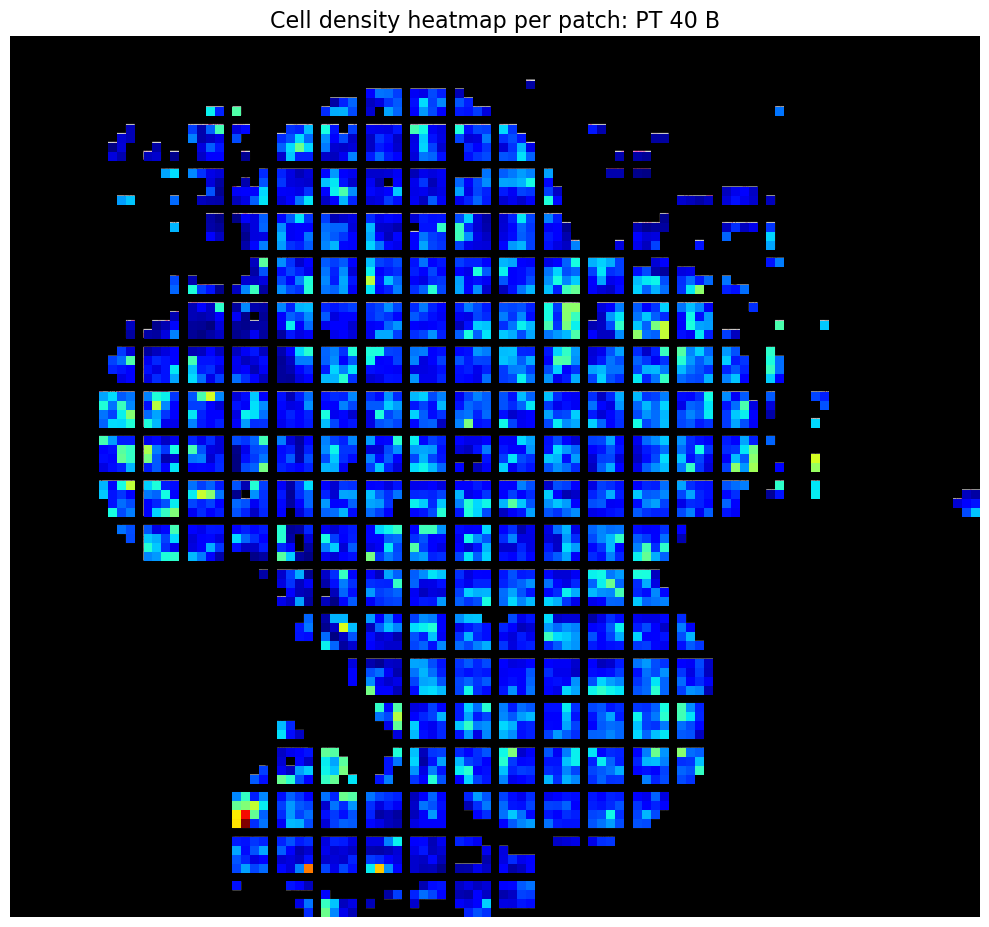

In [20]:
reconstruct_cell_density_heatmap(
    slide_folder=r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B",
    patch_map_csv=r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_map.csv",
    cell_csv=r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_40_B_68um.csv",
    patch_size=(224, 224)
)


# reconstruct_cell_density_heatmap(
#     slide_folder=r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B',
#     patch_map_csv=r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_map.csv",
#     cell_csv=r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B_272um.csv",
#     patch_size=(224, 224)
# )
# reconstruct_cell_density_heatmap(
#     slide_folder=r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\PT\PT 38 B',
#     patch_map_csv=r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\PT\PT 38 B\patch_map.csv",
#     cell_csv=r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\PT_38_B.csv",
#     patch_size=(224, 224)
# )

In [24]:
import pandas as pd

# cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\FA_67_B.csv"   # path to your cell-level csv
cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_40_B_68um.csv"
cells_df = pd.read_csv(cell_csv)

# 1) Count cells per patch
patch_counts = (
    cells_df.groupby("patch_name")
    .size()
    .rename("cell_count")
    .reset_index()
)

# 2a) Print top 10 patches by cell count
top_patches = patch_counts.sort_values("cell_count", ascending=False).head(10)
print(top_patches)

# 2b) Or, print all patches with cell_count >= N
N = 50
high_patches = patch_counts[patch_counts["cell_count"] >= N]
print(high_patches)


                    patch_name  cell_count
1857   patch_2674_x5824_y19712         402
1853   patch_2670_x5824_y19488         360
2043   patch_2841_x7392_y20832         314
2076   patch_2871_x9184_y20832         281
1856   patch_2673_x5600_y19712         269
1851   patch_2669_x5600_y19488         264
1263   patch_2139_x8288_y14784         247
117     patch_1105_x4928_y8960         244
613   patch_1554_x20160_y10528         244
654    patch_1591_x4704_y11424         238
                   patch_name  cell_count
0         patch_0_x4928_y1792         146
1     patch_1000_x14112_y8288          70
2     patch_1001_x13440_y8512         109
4     patch_1003_x13888_y8512          61
5     patch_1004_x14112_y8512         118
...                       ...         ...
2959   patch_995_x13888_y8064         176
2960   patch_996_x14112_y8064         108
2961   patch_997_x13440_y8288          79
2962   patch_998_x13664_y8288         132
2965      patch_9_x8512_y1792          80

[2076 rows x 2 columns

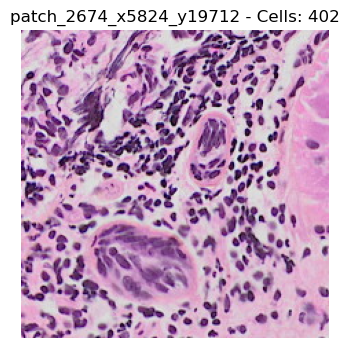

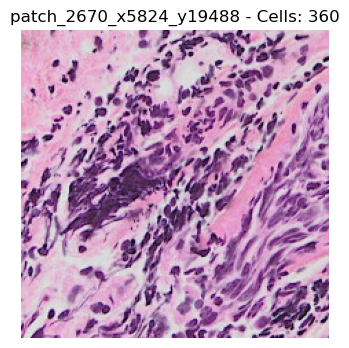

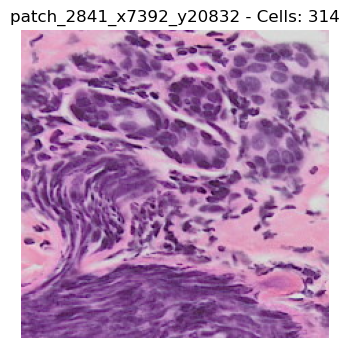

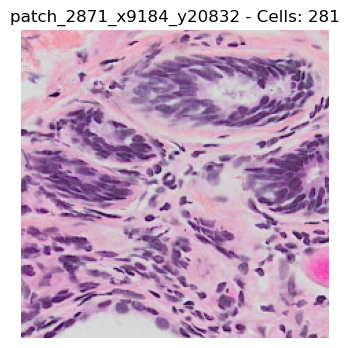

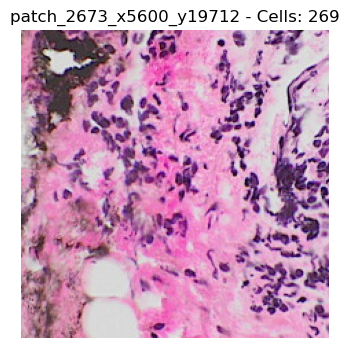

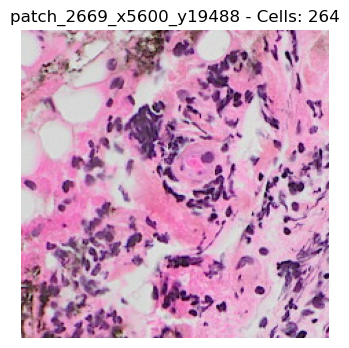

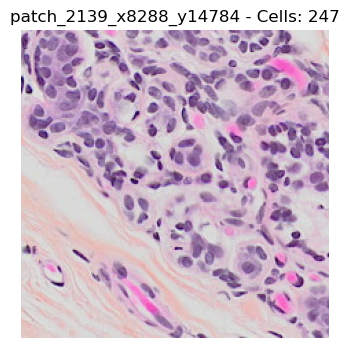

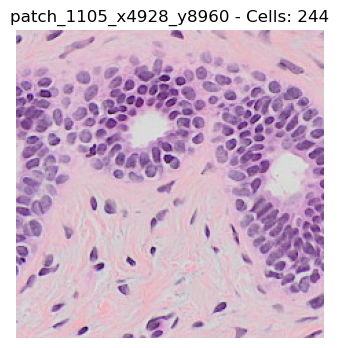

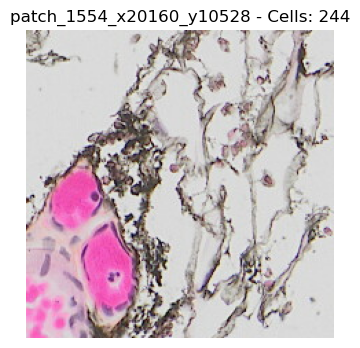

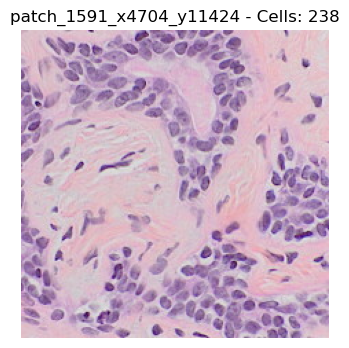

In [25]:
# display top 10 patches with most cells, load npy file and show
# cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_35_B.csv"   # path to your cell-level csv
# patch_dir = r'C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B'
patch_dir = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B"

cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_40_B_68um.csv"

top_patches = patch_counts.sort_values("cell_count", ascending=False).head(10)
top_patches
import matplotlib.pyplot as plt
for _, row in top_patches.iterrows():
    patch_name = row["patch_name"]
    cell_count = row["cell_count"]
    npy_path = Path(patch_dir) / f"{patch_name}.npy"
    patch = np.load(npy_path)

    if patch.ndim == 2:
        patch = np.stack([patch]*3, axis=-1)

    plt.figure(figsize=(4, 4))
    plt.imshow(patch)
    plt.title(f"{patch_name} - Cells: {cell_count}")
    plt.axis("off")
    plt.show()

# iterating over all patches in slide



compute feat stats

In [23]:
import pandas as pd
from pathlib import Path
import numpy as np

# Directory containing your per-slide CSVs
csv_root = Path(r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x")

# Find all slide CSVs
csv_files = sorted(csv_root.glob("*.csv"))

summary_rows = []

for csv_file in csv_files:
    slide_name = csv_file.stem  # e.g., FA_67_B
    df = pd.read_csv(csv_file)

    # --------------------------
    # Basic sanity checks
    # --------------------------
    n_cells = len(df)
    n_patches = df['patch_idx'].nunique()

    # --------------------------
    # Example feature statistics
    # --------------------------

    # 1. Nuclear area (mean, median, std)
    nuc_area_mean = df["Nucleus: Area"].mean()
    nuc_area_median = df["Nucleus: Area"].median()
    nuc_area_std = df["Nucleus: Area"].std()

    # perimeter
    perimeter = df["Nucleus: Perimeter"].mean()
    perimeter_std = df["Nucleus: Perimeter"].std()
    perimeter_median = df["Nucleus: Perimeter"].median()

    # 2. Nucleus/Cell area ratio
    nuc_ratio_mean = df["Nucleus/Cell area ratio"].mean()
    nuc_ratio_std = df["Nucleus/Cell area ratio"].std()

    # 3. Hematoxylin OD (nuclear stain intensity)
    hematox_mean = df["Nucleus: Hematoxylin OD mean"].mean()
    hematox_std = df["Nucleus: Hematoxylin OD mean"].std()

    # 4. Eosin OD (cytoplasm stain intensity)
    eosin_mean = df["Cytoplasm: Eosin OD mean"].mean()
    eosin_std = df["Cytoplasm: Eosin OD mean"].std()

    # 5. Cell count per patch (density)
    cell_count_per_patch_mean = df.groupby("patch_idx").size().mean()
    cell_count_per_patch_std = df.groupby("patch_idx").size().std()

    # Collect stats for this slide
    summary_rows.append({
        "slide": slide_name,
        "num_cells": n_cells,
        "num_patches": n_patches,

        "nucleus_area_mean": nuc_area_mean,
        "nucleus_area_median": nuc_area_median,
        "nucleus_area_std": nuc_area_std,

        "nucleus_cell_ratio_mean": nuc_ratio_mean,
        "nucleus_cell_ratio_std": nuc_ratio_std,

        "hematoxylin_od_mean": hematox_mean,
        "hematoxylin_od_std": hematox_std,

        "eosin_od_mean": eosin_mean,
        "eosin_od_std": eosin_std,

        "cell_count_per_patch_mean": cell_count_per_patch_mean,
        "cell_count_per_patch_std": cell_count_per_patch_std,
        "perimeter_mean": perimeter,
        "perimeter_std": perimeter_std,
        "perimeter_median": perimeter_median
    })

# Create summary dataframe
df_summary = pd.DataFrame(summary_rows)

# Show the summary
df_summary


,slide,num_cells,num_patches,nucleus_area_mean,nucleus_area_median,nucleus_area_std,nucleus_cell_ratio_mean,nucleus_cell_ratio_std,hematoxylin_od_mean,hematoxylin_od_std,eosin_od_mean,eosin_od_std,cell_count_per_patch_mean,cell_count_per_patch_std,perimeter_mean,perimeter_std,perimeter_median
0,FA_56B,70414,3214,40.063453,37.0,18.586257,0.247176,0.087876,0.226840,0.077556,0.096305,0.061096,21.908525,27.889488,24.909573,7.492458,24.10880
1,FA_67_B,117732,7585,39.185566,36.0,18.728402,0.221614,0.073574,0.219489,0.070723,0.100799,0.040791,15.521688,18.572006,24.707929,7.642909,23.58270
2,PT_35_B,115154,7204,39.378293,37.0,16.600216,0.215558,0.063085,0.196798,0.066391,0.111637,0.067010,15.984731,18.568596,24.727881,6.965904,23.78525
3,PT_42_B,98850,4827,44.557309,41.0,20.976676,0.246145,0.080471,0.225185,0.097898,0.079602,0.051080,20.478558,24.651985,26.507856,7.998597,25.52105


     slide class
0   FA_56B    FA
1  FA_67_B    FA
2  PT_35_B    PT
3  PT_42_B    PT

=== Per-class descriptive stats ===
      nucleus_area_mean                                             \
                   mean       std     median        min        max   
class                                                                
FA            39.624509  0.620760  39.624509  39.185566  40.063453   
PT            41.967801  3.662117  41.967801  39.378293  44.557309   

      nucleus_cell_ratio_mean                                          ...  \
                         mean       std    median       min       max  ...   
class                                                                  ...   
FA                   0.234395  0.018075  0.234395  0.221614  0.247176  ...   
PT                   0.230852  0.021628  0.230852  0.215558  0.246145  ...   

      cell_count_per_patch_mean                                             \
                           mean       std     median      

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


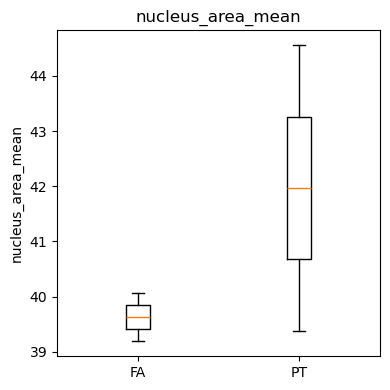

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


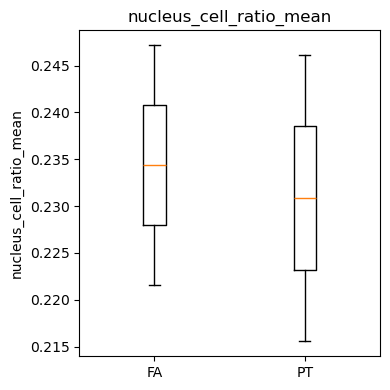

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


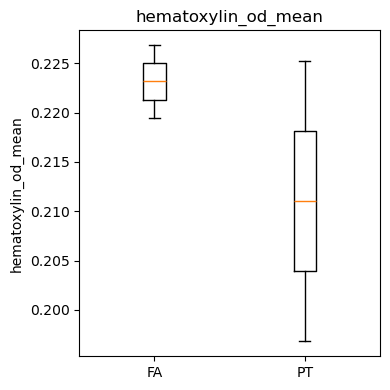

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


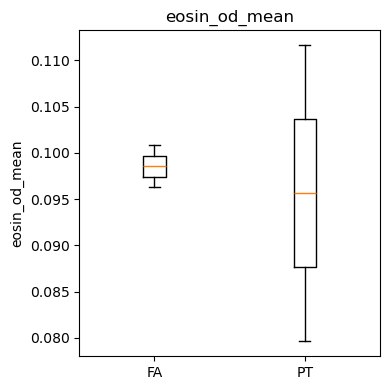

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


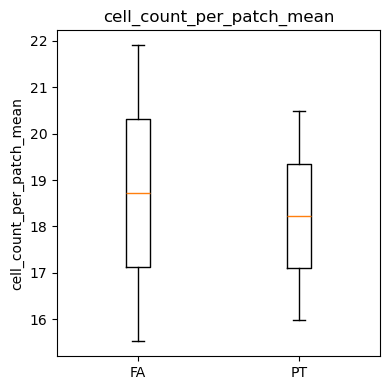

C:\Users\Vivian\AppData\Local\Temp\ipykernel_49472\3273312281.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["FA", "PT"])


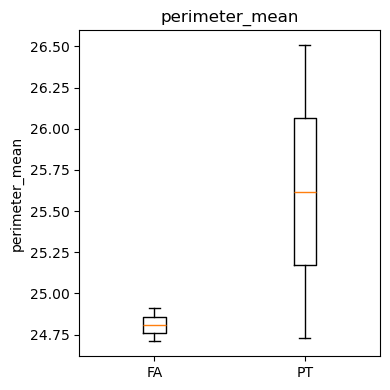

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. If df_summary is already in memory, comment out the next 2 lines
# ------------------------------------------------------------------
# df_summary = pd.read_csv(r"C:\path\to\your\df_summary.csv")

# ------------------------------------------------------------------
# 2. Add class label (FA / PT) parsed from slide name
# ------------------------------------------------------------------
df = df_summary.copy()
df["class"] = df["slide"].str.split("_").str[0]   # 'FA_56B' -> 'FA', 'PT_35_B' -> 'PT'

print(df[["slide", "class"]].head())

# ------------------------------------------------------------------
# 3. Choose metrics to compare
# ------------------------------------------------------------------
metrics = [
    "nucleus_area_mean",
    "nucleus_cell_ratio_mean",
    "hematoxylin_od_mean",
    "eosin_od_mean",
    "cell_count_per_patch_mean",
    "perimeter_mean"
]

# Quick sanity: ensure all metrics exist
missing = [m for m in metrics if m not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# ------------------------------------------------------------------
# 4. Per-class descriptive stats
# ------------------------------------------------------------------
print("\n=== Per-class descriptive stats ===")
group_stats = (
    df.groupby("class")[metrics]
      .agg(["mean", "std", "median", "min", "max"])
)
print(group_stats)

# ------------------------------------------------------------------
# 5. FA vs PT t-tests for each metric
# ------------------------------------------------------------------
print("\n=== FA vs PT t-tests (Welch) ===")
fa = df[df["class"] == "FA"]
pt = df[df["class"] == "PT"]

for m in metrics:
    fa_vals = fa[m].dropna()
    pt_vals = pt[m].dropna()
    if len(fa_vals) < 2 or len(pt_vals) < 2:
        print(f"{m}: not enough data for t-test (FA={len(fa_vals)}, PT={len(pt_vals)})")
        continue

    t_stat, p_val = stats.ttest_ind(fa_vals, pt_vals, equal_var=False)
    print(f"{m}:")
    print(f"  FA mean = {fa_vals.mean():.3f}, PT mean = {pt_vals.mean():.3f}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.3g}")
    print()

# ------------------------------------------------------------------
# 6. (Optional) Boxplots for quick visual comparison
# ------------------------------------------------------------------
make_plots = True

if make_plots:
    for m in metrics:
        plt.figure(figsize=(4, 4))
        data = [fa[m].dropna(), pt[m].dropna()]
        plt.boxplot(data, labels=["FA", "PT"])
        plt.title(m)
        plt.ylabel(m)
        plt.tight_layout()
        plt.show()


thresholding patches before cell detection

In [29]:
import numpy as np
from pathlib import Path

# H&E stain matrix similar to QuPath's default (rows = stain, cols = RGB)
HE_MATRIX = np.array([
    [0.65111, 0.70119, 0.29049],  # Hematoxylin
    [0.21590, 0.80120, 0.55810],  # Eosin
    [0.0    , 0.0    , 0.0    ],  # third stain unused
], dtype=np.float32)


def rgb_to_he_od(patch_rgb):
    """
    Convert RGB uint8 patch (H,W,3) to OD H & E channels.
    Returns H_od, E_od as float32 arrays (H,W).
    """
    # Ensure float in [0,1]
    I = patch_rgb.astype(np.float32) / 255.0
    I[I <= 0] = 1e-6

    # Optical density
    OD = -np.log(I)

    # Invert stain matrix (use first 2 stains only)
    M = HE_MATRIX[:2, :]  # (2,3)
    M_inv = np.linalg.pinv(M)  # (3,2)

    # Shape (H,W,3) -> (H*W,3)
    h, w, _ = OD.shape
    OD_flat = OD.reshape(-1, 3)

    # Stain concentrations: (H*W,2)
    C = OD_flat @ M_inv  # approximate

    H_od = C[:, 0].reshape(h, w)
    E_od = C[:, 1].reshape(h, w)
    return H_od, E_od


def compute_patch_stain_stats(npy_path):
    """
    Load a .npy patch, compute median H & E OD.
    Returns dict with stats + path.
    """
    npy_path = Path(npy_path)
    patch = np.load(npy_path)

    if patch.ndim == 2:
        patch = np.stack([patch] * 3, axis=-1)

    # clip to uint8 range if needed
    if patch.dtype != np.uint8:
        patch = np.clip(patch, 0, 255).astype(np.uint8)

    H_od, E_od = rgb_to_he_od(patch)

    stats = {
        "patch_path": str(npy_path),
        "patch_name": npy_path.stem,
        "H_median": float(np.median(H_od)),
        "E_median": float(np.median(E_od)),
        "H_mean": float(np.mean(H_od)),
        "E_mean": float(np.mean(E_od)),
    }
    return stats


In [30]:
def classify_patch_by_stain(H_median, E_median,
                            H_gland_thresh=0.25,
                            E_stroma_thresh=0.12):
    """
    Rough heuristic:
      - glands/epithelium: H high
      - stroma: E high, H not too high
    """
    if H_median >= H_gland_thresh and E_median >= E_stroma_thresh:
        return "gland_or_epithelium"
    elif E_median >= E_stroma_thresh and H_median < H_gland_thresh:
        return "stroma"
    else:
        return "low_tissue_or_other"


In [ ]:
from glob import glob
import pandas as pd

patch_dir = r"C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\FA\FA 57B"
patch_paths = sorted(glob(str(Path(patch_dir) / "*.npy")))

rows = []
for p in patch_paths:
    stats = compute_patch_stain_stats(p)
    label = classify_patch_by_stain(stats["H_median"], stats["E_median"])
    stats["stain_class"] = label
    rows.append(stats)

df_stain = pd.DataFrame(rows)
df_stain.head()


,patch_path,patch_name,H_median,E_median,H_mean,E_mean,stain_class
0,C:\Users\Vivian\Documents\CONCH\patches_tiled\...,patch_0_x9184_y672,0.154163,0.090580,0.112587,0.338884,low_tissue_or_other
1,C:\Users\Vivian\Documents\CONCH\patches_tiled\...,patch_1000_x26208_y4480,0.144240,0.256582,0.118735,0.283401,stroma
2,C:\Users\Vivian\Documents\CONCH\patches_tiled\...,patch_1001_x26432_y4480,0.152277,0.124735,0.149657,0.172592,stroma
3,C:\Users\Vivian\Documents\CONCH\patches_tiled\...,patch_1002_x25760_y4704,0.112187,0.302803,0.121581,0.315237,stroma
4,C:\Users\Vivian\Documents\CONCH\patches_tiled\...,patch_1003_x25984_y4704,0.100688,0.342579,0.117267,0.362245,stroma


In [34]:
# save df
out_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\FA_57B_stain_stats.csv"
df_stain.to_csv(out_csv, index=False)


In [36]:
df_stain.describe()


,H_median,E_median,H_mean,E_mean
count,5385.000000,5385.000000,5385.000000,5385.000000
mean,0.007587,0.588634,0.040163,0.605768
std,0.100508,0.208183,0.084873,0.184029
min,-0.207196,0.087798,-0.164847,0.142050
25%,-0.076111,0.478843,-0.026564,0.483733
50%,-0.010431,0.602464,0.032602,0.609339
75%,0.095129,0.718846,0.102120,0.725153
max,0.359190,2.386726,0.374828,2.403736


In [37]:
df_stain.groupby("stain_class")[["H_median", "E_median", "H_mean", "E_mean"]].describe()


H_median                                          \
                       count      mean       std       min       25%   
stain_class                                                            
gland_or_epithelium      3.0  0.327195  0.027715  0.310586  0.311198   
low_tissue_or_other    181.0  0.164763  0.007155  0.149163  0.159185   
stroma                5201.0  0.001933  0.097501 -0.207196 -0.077586   

                                                  E_median            ...  \
                          50%       75%       max    count      mean  ...   
stain_class                                                           ...   
gland_or_epithelium  0.311810  0.335500  0.359190      3.0  2.343465  ...   
low_tissue_or_other  0.164230  0.169298  0.179503    181.0  0.102111  ...   
stroma              -0.017392  0.082641  0.242081   5201.0  0.604553  ...   

                       H_mean            E_mean                                \
                          75%       max   count      mean       std       min   
stain_class                                                                     
gland_or_epithelium  0.342983  0.370131     3.0  2.254518  0.198725  2.028939   
low_tissue_or_other  0.191211  0.334076   181.0  0.283963  0.101376  0.142050   
stroma               0.095139  0.374828  5201.0  0.616016  0.171511  0.172592   

                                                             
                          25%       50%       75%       max  
stain_class                                                  
gland_or_epithelium  2.179910  2.330881  2.367308  2.403736  
low_tissue_or_other  0.203730  0.261872  0.339629  0.725977  
stroma               0.496184  0.615824  0.729092  2.003839  

[3 rows x 32 columns]

In [38]:
df_stain["stain_class"].value_counts()


stain_class
stroma                 5201
low_tissue_or_other     181
gland_or_epithelium       3
Name: count, dtype: int64

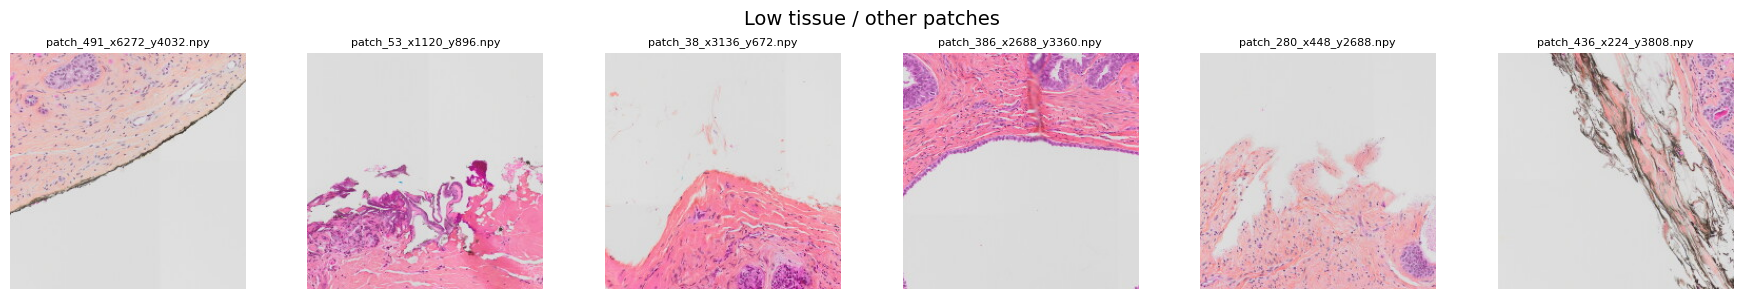

NameError: name 'gland_samples' is not defined

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Load your stain stats CSV
csv_path = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B_stain_stats_extended.csv"
df = pd.read_csv(csv_path)

# 2) Filter by stain_class
# low_tissue_df = df[df["stain_class"] == "low_tissue_or_other"]
# gland_df      = df[df["stain_class"] == "gland_or_epithelium"]

# print("low_tissue_or_other patches:", len(low_tissue_df))
# print("gland_or_epithelium patches:", len(gland_df))

# 3) Sample a few from each
# n_show = 6  # adjust as you like
# low_samples   = low_tissue_df.sample(min(n_show, len(low_tissue_df)), random_state=0)
# gland_samples = gland_df.sample(min(n_show, len(gland_df)), random_state=0)

def load_patch(npy_path):
    arr = np.load(npy_path)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr

# 4) Helper to plot a row of patches
def show_patch_row(sample_df, title):
    if sample_df.empty:
        print(f"No patches to show for {title}")
        return

    n = len(sample_df)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        patch_path = row["patch_path"]
        img = load_patch(patch_path)
        ax.imshow(img)
        ax.set_title(Path(patch_path).name, fontsize=8)
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# 5) Visualize
show_patch_row(low_samples,   "Low tissue / other patches")
show_patch_row(gland_samples, "Gland / epithelium-like patches")


<Axes: title={'center': 'E_median'}, ylabel='Frequency'>

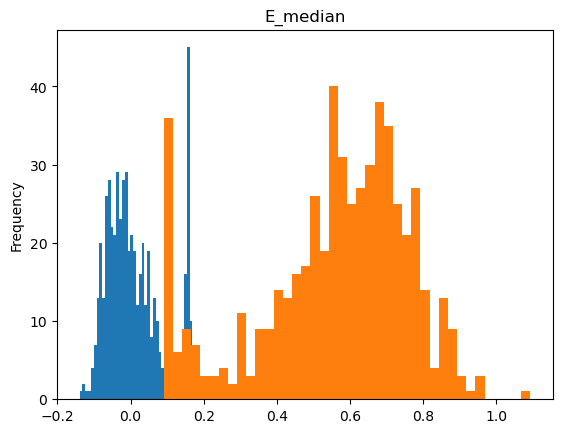

In [12]:
df_stain[["H_median","E_median"]].describe()
df_stain["H_median"].plot(kind="hist", bins=40, title="H_median")

df_stain["E_median"].plot(kind="hist", bins=40, title="E_median")


<Axes: title={'center': 'H_median'}, ylabel='Frequency'>

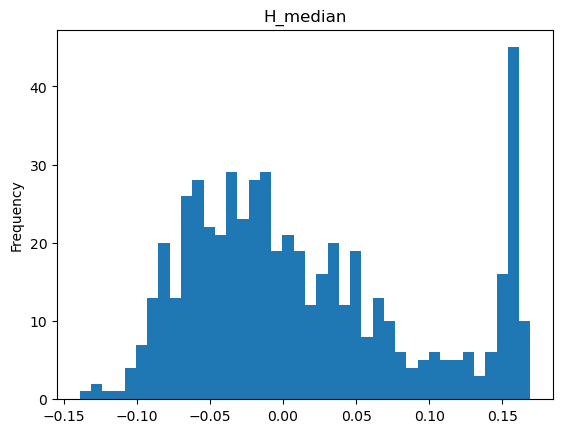

In [13]:
df_stain["H_median"].plot(kind="hist", bins=40, title="H_median")


In [1]:
import numpy as np
from matplotlib.colors import rgb_to_hsv

def rgb_to_he_od(patch_rgb):
    HE_MATRIX = np.array([
        [0.65111, 0.70119, 0.29049],  # Hematoxylin
        [0.21590, 0.80120, 0.55810],  # Eosin
        [0.0    , 0.0    , 0.0    ],
    ], dtype=np.float32)

    I = patch_rgb.astype(np.float32) / 255.0
    I[I <= 0] = 1e-6
    OD = -np.log(I)

    M = HE_MATRIX[:2, :]
    M_inv = np.linalg.pinv(M)

    h, w, _ = OD.shape
    OD_flat = OD.reshape(-1, 3)
    C = OD_flat @ M_inv

    H_od = C[:, 0].reshape(h, w)
    E_od = C[:, 1].reshape(h, w)
    return H_od, E_od


def compute_patch_stain_color_stats(npy_path):
    patch = np.load(npy_path)

    if patch.ndim == 2:
        patch = np.stack([patch]*3, axis=-1)
    if patch.dtype != np.uint8:
        patch = np.clip(patch, 0, 255).astype(np.uint8)

    H_od, E_od = rgb_to_he_od(patch)

    # --- H&E stats ---
    H_median = float(np.median(H_od))
    E_median = float(np.median(E_od))
    H_mean   = float(np.mean(H_od))
    E_mean   = float(np.mean(E_od))

    # --- RGB stats ---
    rgb = patch.astype(np.float32) / 255.0
    R_mean = float(rgb[...,0].mean())
    G_mean = float(rgb[...,1].mean())
    B_mean = float(rgb[...,2].mean())

    # --- HSV stats ---
    hsv = rgb_to_hsv(rgb.reshape(-1,3)).reshape(rgb.shape)
    H_hsv_mean = float(hsv[...,0].mean())   # hue
    S_mean     = float(hsv[...,1].mean())   # saturation
    V_mean     = float(hsv[...,2].mean())   # value/brightness

    # --- fraction of very bright pixels (background/empty) ---
    gray = rgb.mean(axis=-1)
    bright_fraction = float((gray > 0.95).mean())

    return {
        "patch_path": str(npy_path),
        "patch_name": Path(npy_path).stem,
        "H_median": H_median,
        "E_median": E_median,
        "H_mean": H_mean,
        "E_mean": E_mean,
        "R_mean": R_mean,
        "G_mean": G_mean,
        "B_mean": B_mean,
        "H_hsv_mean": H_hsv_mean,
        "S_mean": S_mean,
        "V_mean": V_mean,
        "bright_fraction": bright_fraction,
    }


In [14]:
from glob import glob
import pandas as pd
import numpy as np
from pathlib import Path 

patch_dir = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_10x\20x\FA\FA 57B"
patch_paths = sorted(glob(str(Path(patch_dir) / "*.npy")))

rows = []
for p in patch_paths:
    stats = compute_patch_stain_color_stats(p)   # <-- NEW FUNCTION
    rows.append(stats)

df_stain = pd.DataFrame(rows)


In [4]:
print(df_stain.columns)


Index(['patch_path', 'patch_name', 'H_median', 'E_median', 'H_mean', 'E_mean',
       'R_mean', 'G_mean', 'B_mean', 'H_hsv_mean', 'S_mean', 'V_mean',
       'bright_fraction'],
      dtype='object')


In [5]:
df_stain.to_csv("C:\\Users\\Vivian\\Documents\\qupath_ann_testing\\cell_csv\\2.5x\\FA_57B_stain_stats_extended.csv", index=False)

In [15]:
def classify_patch_by_stain_color(row):
    Hm = row["H_median"]
    Em = row["E_median"]
    V  = row["V_mean"]
    S  = row["S_mean"]
    bright_frac = row["bright_fraction"]

    # 1) Low tissue / background / fat / junk
    if Em < 0.12 or bright_frac > 0.5 or (V > 0.9 and S < 0.2):
        return "low_tissue"

    # 2) Epithelium / glands:
    #    - higher hematoxylin
    #    - darker (lower V)
    #    - reasonably saturated
    if (Hm >= 0.12) and (V < 0.85) and (S > 0.25):
        return "epithelium_or_gland"

    # 3) Everything else = stroma
    return "stroma"


df_stain["stain_class"] = df_stain.apply(classify_patch_by_stain_color, axis=1)
print(df_stain["stain_class"].value_counts())


ValueError: Cannot set a DataFrame without columns to the column stain_class

In [16]:
n_show = 6
low_df   = df_stain[df_stain["stain_class"] == "low_tissue"]
strom_df = df_stain[df_stain["stain_class"] == "stroma"]
epi_df   = df_stain[df_stain["stain_class"] == "epithelium_or_gland"]

low_samples   = low_df.sample(min(n_show, len(low_df)), random_state=0)
strom_samples = strom_df.sample(min(n_show, len(strom_df)), random_state=0)
epi_samples   = epi_df.sample(min(n_show, len(epi_df)), random_state=0)

show_patch_row(low_samples,   "Low tissue patches")
show_patch_row(strom_samples, "Stroma patches")
show_patch_row(epi_samples,   "Epithelium / gland patches")


KeyError: 'stain_class'

Patch: C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x\20x\FA\FA 57B\patch_100_x5824_y1120.npy


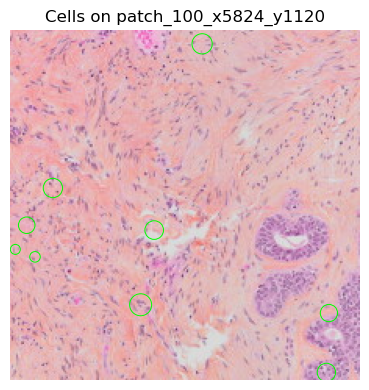

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pathlib import Path

csv_path = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B.csv"  # your cell TSV/CSV

# --- 1. Load cell table ---
df = pd.read_csv(csv_path)

# Fix the µ character if it came through as 'Âµ'
df = df.rename(columns=lambda c: c.replace("Âµ", "µ"))

# Pick one patch to visualize
patch_name = "patch_100_x5824_y1120"   # change as needed
df_patch = df[df["patch_name"] == patch_name].copy()

if df_patch.empty:
    raise ValueError(f"No rows found for patch_name={patch_name}")

patch_path = df_patch["patch_path"].iloc[0]
print("Patch:", patch_path)

# --- 2. Load patch image ---
patch = np.load(patch_path)
if patch.ndim == 2:
    patch = np.stack([patch]*3, axis=-1)
if patch.dtype != np.uint8:
    patch = np.clip(patch, 0, 255).astype(np.uint8)

# --- 3. Convert centroids (µm) → pixels ---
MICRONS_PER_PIXEL = 0.5  # from WatershedCellDetection 'requestedPixelSizeMicrons'

x_um = df_patch["Centroid X µm"].values
y_um = df_patch["Centroid Y µm"].values

x_px = x_um / MICRONS_PER_PIXEL
y_px = y_um / MICRONS_PER_PIXEL

# Approximate nucleus radius from area (area is in µm²)
areas_um2 = df_patch["Nucleus: Area"].values
r_px = np.sqrt(areas_um2 / np.pi) / MICRONS_PER_PIXEL

# --- 4. Plot patch + cell masks ---
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(patch)
ax.set_title(f"Cells on {patch_name}")
ax.axis("off")

for x, y, r in zip(x_px, y_px, r_px):
    circ = Circle((x, y), r,
                  edgecolor="lime",
                  facecolor="none",
                  linewidth=0.7)
    ax.add_patch(circ)

plt.tight_layout()
plt.show()


Most dense patch: patch_2830_x6720_y20384 with 87 cells
Patch file: C:\Users\Vivian\Documents\CONCH\patches_tiled\patches_10x\20x\PT\PT 40 B\patch_2830_x6720_y20384.npy
Found 87 nuclei polygons for this patch


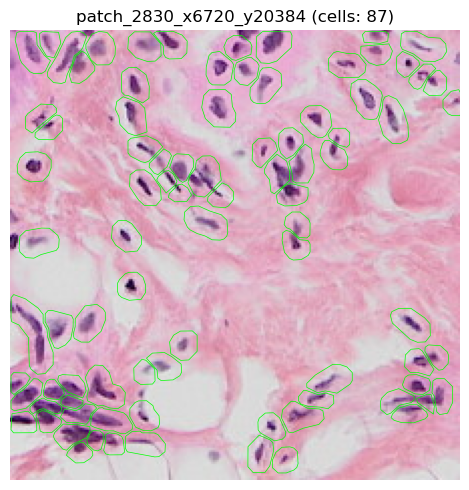

In [30]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# --- 1. Load cell CSV + slide-level GeoJSON ---

# cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\2.5x\FA_57B_272um.csv"
# geojson_path = r"C:\Users\Vivian\Documents\qupath_ann_testing\masks\2.5x\FA_57B_nuclei.geojson"

cell_csv = r"C:\Users\Vivian\Documents\qupath_ann_testing\cell_csv\10x\PT_40_B_68um.csv"
geojson_path = r"C:\Users\Vivian\Documents\qupath_ann_testing\masks\10x\PT_40_B_nuclei.geojson"

df_cells = pd.read_csv(cell_csv)

with open(geojson_path, "r") as f:
    gj = json.load(f)

# --- 2. Find the most dense patch (max cell count) ---

# group by patch_name; you could also group by patch_idx if you prefer
counts = df_cells.groupby("patch_name")["Object ID"].count().sort_values(ascending=False)

top_patch_name = counts.index[1000]
top_cell_count = counts.iloc[1000]
print(f"Most dense patch: {top_patch_name} with {top_cell_count} cells")

# get patch_path for that patch
top_patch_path = df_cells.loc[df_cells["patch_name"] == top_patch_name, "patch_path"].iloc[0]
print("Patch file:", top_patch_path)

# --- 3. Filter GeoJSON to this patch only ---

patch_features = [
    feat for feat in gj.get("features", [])
    if feat.get("properties", {}).get("patch_name") == top_patch_name
]

print(f"Found {len(patch_features)} nuclei polygons for this patch")

# --- 4. Load the patch image (.npy) ---

patch = np.load(top_patch_path)
if patch.ndim == 2:
    patch = np.stack([patch] * 3, axis=-1)
if patch.dtype != np.uint8:
    patch = np.clip(patch, 0, 255).astype(np.uint8)

# --- 5. Visualize patch + polygon annotations ---

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(patch)
ax.set_title(f"{top_patch_name} (cells: {top_cell_count})")
ax.axis("off")

for feat in patch_features:
    geom = feat.get("geometry", {})
    if geom.get("type") != "Polygon":
        continue
    # GeoJSON: coordinates = [ [ [x1,y1], [x2,y2], ... ] ]  (list of rings)
    for ring in geom.get("coordinates", []):
        poly = Polygon(ring, closed=True, fill=False,
                       edgecolor="lime", linewidth=0.5)
        ax.add_patch(poly)

plt.tight_layout()
plt.show()
